In [75]:
from kaggle_environments import make

env = make('connectx')

rows = env.configuration.rows
columns = env.configuration.columns
inarow = env.configuration.inarow

assert rows == 6
assert columns == 7
assert inarow == 4

In [76]:
import torch
import numpy as np
import os

def seed_everything(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

seed_everything(42)

In [77]:
class My_DQN(torch.nn.Module):
    def __init__(self, env_config, my_config, device='cpu'):
        super().__init__()
        self.env_config = env_config

        self.model = torch.nn.Sequential(
            torch.nn.Linear(env_config.rows * env_config.columns, my_config.h, device=device),
            torch.nn.ReLU(),
            torch.nn.Linear(my_config.h, my_config.h, device=device),
            torch.nn.ReLU(),
            torch.nn.Linear(my_config.h, my_config.h, device=device),
            torch.nn.ReLU(),
            torch.nn.Linear(my_config.h, env_config.columns, device=device)
        )

    def forward(self, X):
        assert X.shape[-1] == self.env_config.rows * self.env_config.columns
        return self.model(X.to(dtype=torch.float32))


In [78]:
from types import SimpleNamespace

device = 'cuda'
env_config = env.configuration
my_config = SimpleNamespace(
    h=128
)

Q_func = My_DQN(env_config, my_config, device)

In [79]:
Y = Q_func(torch.ones(5, 42, device=device))
print(Y)

tensor([[-0.0084, -0.0341, -0.0550, -0.0520, -0.0039,  0.0553, -0.0062],
        [-0.0084, -0.0341, -0.0550, -0.0520, -0.0039,  0.0553, -0.0062],
        [-0.0084, -0.0341, -0.0550, -0.0520, -0.0039,  0.0553, -0.0062],
        [-0.0084, -0.0341, -0.0550, -0.0520, -0.0039,  0.0553, -0.0062],
        [-0.0084, -0.0341, -0.0550, -0.0520, -0.0039,  0.0553, -0.0062]],
       device='cuda:0', grad_fn=<AddmmBackward0>)


---


Initialize replay memory $D$ to capacity $N$

Initialize action-value function $Q$ with random weights $\theta$

Initialize target action-value function $\hat{Q}$ with weights $\theta^- = \theta$

**For** episode $= 1, M$ **do**

$\quad$ Initialize sequence $s_1 = \{x_1\}$ and preprocessed sequence $\phi_1 = \phi(s_1)$

$\quad$ **For** $t = 1, T$ **do**

$\qquad$ With probability $\varepsilon$ select a random action $a_t$

$\qquad$ otherwise select $a_t = \text{argmax}_a Q(\phi(s_t), a; \theta)$

$\qquad$ Execute action $a_t$ in emulator and observe reward $r_t$ and image $x_{t+1}$

$\qquad$ Set $s_{t+1} = s_t, a_t, x_{t+1}$ and preprocess $\phi_{t+1} = \phi(s_{t+1})$

$\qquad$ Store transition $(\phi_t, a_t, r_t, \phi_{t+1})$ in $D$

$\qquad$ Sample random minibatch of transitions $(\phi_j, a_j, r_j, \phi_{j+1})$ from $D$

$\qquad$ Set $y_j = \begin{cases} r_j & \text{if episode terminates at step } j+1 \\ r_j + \gamma \max_{a'} \hat{Q}(\phi_{j+1}, a'; \theta^-) & \text{otherwise} \end{cases}$

$\qquad$ Perform a gradient descent step on $\left(y_j - Q(\phi_j, a_j; \theta)\right)^2$ with respect to the network parameters $\theta$

$\qquad$ Every $C$ steps reset $\hat{Q} = Q$

$\quad$ **End For**

**End For**

In [80]:
def process_state(obs, device='cpu'):
    board = torch.tensor(obs.board, device=device)

    opponent_mark = 2 if obs.mark == 1 else 1
    board[board==opponent_mark] = -1
    board[board==obs.mark] == 1

    return board

class Memory:
    def __init__(self, env_config, train_config, device='cpu'):
        self.train_config = train_config

        self.state = torch.zeros(
            train_config.total_steps, 
            env_config.rows * env_config.columns,
            device=device
        )
        self.action = torch.zeros(train_config.total_steps, device=device, dtype=torch.int64)
        self.reward = torch.zeros(train_config.total_steps, device=device)
        self.next_state = torch.zeros(
            train_config.total_steps, 
            env_config.rows * env_config.columns,
            device=device
        )
        self.done = torch.zeros(train_config.total_steps, device=device, dtype=bool)

        self._at = 0

    def __len__(self):
        return self._at

    def write(self, state, action, reward, next_state, done):
        at = self._at
        self.state[at] = state
        self.action[at] = action
        self.reward[at] = reward
        self.next_state[at] = next_state
        self.done[at] = done

        self._at += 1
        
    def sample_minibatch(self):
        idx = torch.randperm(self._at)[:self.train_config.batch_size]

        return (
            self.state[idx],
            self.action[idx],
            self.reward[idx],
            self.next_state[idx],
            self.done[idx]
        )

In [81]:
reward_for_inarow = torch.arange(inarow + 1, device=device) / inarow
reward_for_inarow[:2] = 0

train_config = SimpleNamespace(
    batch_size = 32,
    total_steps = 1000,
    epsilon = 0.1, # ???
    reward_for_None = -5,
    reward_for_inarow = reward_for_inarow,
    state_reward_coeff = 0.01
)

In [82]:
# def compute_reward(reward, state, action, env_config, train_config):
#     if reward is None:
#         return train_config.reward_for_None

#     rows = env_config.rows
#     columns = env_config.columns
#     inarow = env_config.inarow

#     state = state.view(rows, columns)
    
#     def count_inarow(dx, dy, mark):
#         cur_inarow = 1
#         x = action + dx
#         y = (state[:,action]==0).sum() + dy

#         while 0 <= x < columns and 0 <= y < rows and state[y,x] == mark: 
#             cur_inarow += 1
#             x += dx
#             y += dy

#         return cur_inarow
    
#     def valid_inarow(dx, dy):
#         cur_inarow = count_inarow(dx, dy, mark=1)
#         empty_inarow = count_inarow(-dx, -dy, mark=0)

#         if empty_inarow - 1 >= inarow - cur_inarow:
#             return cur_inarow
#         return 0
    
#     for dx, dy in [(-1, 0), (1, 0), (-1, 1), (1, 1), (0, 1), (-1, 1), (1, 1)]:
#         reward += train_config.reward_for_inarow[valid_inarow(dx, dy)]
    
#     return reward

In [83]:
def estimate_state(state, env_config, train_config, device):
    rows = env_config.rows
    columns = env_config.columns
    inarow = env_config.inarow

    state = state.view(rows, columns)


    def count_inarow(row):    
        total_inarow = torch.zeros(inarow + 1, device=device, dtype=torch.int64)
        cur_inarow = torch.zeros(inarow + 1, device=device, dtype=torch.int64)
        num_empty = 0
        num_inarow = 0
        
        EMPTY = 0
        OPPONENT = -1
        MARK = 1

        last_cell = OPPONENT


        def process_end_of_inarow(total_inarow, cur_inarow):
            if last_cell == MARK:
                cur_inarow[num_inarow] += 1

            # validate inarow
            weights = torch.arange(inarow + 1, device=device)
            if (cur_inarow * weights).sum().item() + num_empty >= inarow:
                total_inarow += cur_inarow

            return total_inarow, cur_inarow


        for cell in row:
            if cell == MARK:
                num_inarow += 1

            if cell == EMPTY:
                num_empty += 1
                if last_cell == MARK:
                    cur_inarow[num_inarow] += 1
                    num_inarow = 0
                
            if cell == OPPONENT:
                total_inarow, cur_inarow = process_end_of_inarow(total_inarow, cur_inarow)
                cur_inarow = torch.zeros(inarow + 1, device=device, dtype=torch.int64)
                num_inarow = 0
                num_empty = 0

            last_cell = cell

        total_inarow, cur_inarow = process_end_of_inarow(total_inarow, cur_inarow)
            
        return total_inarow

    total_inarow = torch.zeros(inarow + 1, device=device)

    for _state in [state, state.T]:
        for row in _state:
            total_inarow += count_inarow(row)

    for _state in [state, state.fliplr()]:
        for offset in range(-1 * (rows - inarow), columns - inarow + 1):
            row = _state.diag(offset)
            total_inarow += count_inarow(row)

    return total_inarow * train_config.reward_for_inarow


def compute_reward(reward, state, next_state, env_config, train_config, device):
    if reward is None:
        return train_config.reward_for_None
    
    state_value = estimate_state(state, env_config, train_config, device)
    next_state_value = estimate_state(next_state, env_config, train_config, device)

    return reward + (train_config.state_reward_coeff * (next_state_value - state_value)).sum().item()


In [84]:
print(inarow)
state = torch.tensor([
    [ 0,  0,  0,  0,  0,  0,  0],
    [ 0,  0,  0,  0,  0,  0,  0],
    [ 0,  0,  0,  0, -1,  0,  0],
    [ 0,  0,  0,  1,  1,  0,  0],
    [ 0,  0,  0, -1, -1,  0,  0],
    [ 1,  0, -1,  1,  1, -1,  0]], device=device)

next_state = torch.tensor([
    [ 0,  0,  0,  0,  0,  0,  0],
    [ 0,  0,  0,  0,  0,  0,  0],
    [ 0,  0,  0,  0, -1,  0,  0],
    [ 0,  0,  0,  1,  1,  0,  0],
    [ 0,  0,  1, -1, -1,  0,  0],
    [ 1,  -1, -1,  1,  1, -1,  0]], device=device)

# print(estimate_state(state, env_config, train_config, device))
print(compute_reward(0, state, next_state, env_config, train_config, device))

4
0.004999999888241291


In [85]:
# def count_inarow(row):    
#     total_inarow = torch.zeros(inarow + 1, device=device, dtype=torch.int64)
#     cur_inarow = torch.zeros(inarow + 1, device=device, dtype=torch.int64)
#     num_empty = 0
#     num_inarow = 0

#     EMPTY = 0
#     OPPONENT = -1
#     MARK = 1

#     last_cell = OPPONENT

#     def process_end_of_inarow(total_inarow, cur_inarow):
#         if last_cell == MARK:
#             cur_inarow[num_inarow] += 1

#         # validate inarow
#         weights = torch.arange(inarow + 1, device=device)
#         if (cur_inarow * weights).sum().item() + num_empty >= inarow:
#             total_inarow += cur_inarow

#         return total_inarow, cur_inarow

#     for cell in row:
#         if cell == MARK:
#             num_inarow += 1

#         if cell == EMPTY:
#             num_empty += 1
#             if last_cell == MARK:
#                 cur_inarow[num_inarow] += 1
#                 num_inarow = 0
            
#         if cell == OPPONENT:
#             total_inarow, cur_inarow = process_end_of_inarow(total_inarow, cur_inarow)
#             cur_inarow = torch.zeros(inarow + 1, device=device, dtype=torch.int64)
#             num_inarow = 0
#             num_empty = 0

#         last_cell = cell

#     total_inarow, cur_inarow = process_end_of_inarow(total_inarow, cur_inarow)
        
#     return total_inarow

# count_inarow(torch.tensor([-1, -1, 1, 0, 0],))


In [86]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import LinearLR

optimizer = AdamW(Q_func.parameters())
scheduler = LinearLR(
    optimizer, 
    start_factor=0.1, 
    end_factor=1, 
    total_iters=(train_config.total_steps - 2 * train_config.batch_size) / 2)

In [87]:
def train(Q_func, optimizer, scheduler, my_config, env_config, train_config, op_agent='random', device='cpu'):
    logs = {'loss': [], 'lr': []}
    memory = Memory(env_config, train_config, device)

    Q_func_hat = My_DQN(env_config, my_config, device)
    Q_func_hat.load_state_dict(Q_func.state_dict())

    Q_func.train()
    Q_func_hat.eval()

    trainer = env.train([None, op_agent])
    done = False
    obs = trainer.reset()
    state = process_state(obs, device)

    for step in range(train_config.total_steps):
        if step % 100 == 0:
            print('step:', step)
            
        if torch.rand(1) <= train_config.epsilon:
            action = int(np.random.choice(
                [c for c in range(env_config.columns) if state[c] == 0]
            ))
        else:
            action = Q_func(state[None,:]).argmax(dim=-1).item()

        obs, reward, done, _ = trainer.step(action)
        next_state = process_state(obs, device)
        # if reward is None: reward = train_config.reward_for_None
        reward = compute_reward(reward, state, next_state, env_config, train_config, device)

        memory.write(state, action, reward, next_state, done)

        if len(memory) >= train_config.batch_size * 2: # ???
            states, actions, rewards, next_states, dones = memory.sample_minibatch()
            
            with torch.no_grad():
                target_rewards = rewards + Q_func_hat(next_states).max(dim=-1).values * ~dones
            pred_rewards = Q_func(states)[torch.arange(train_config.batch_size, device=device),actions]

            loss = (1 / train_config.batch_size) * torch.square(target_rewards - pred_rewards).sum()
            logs['loss'].append(loss.item())
            logs['lr'].append(optimizer.param_groups[0]['lr'])

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            scheduler.step()

        if done:
            obs = trainer.reset()
            state = process_state(obs, device)
        else:
            state = next_state
    
    return logs

In [88]:
logs = train(Q_func, optimizer, scheduler, my_config, env_config, train_config, op_agent='random', device=device)

step: 0


step: 100
step: 200
step: 300
step: 400
step: 500
step: 600
step: 700
step: 800
step: 900


In [89]:
# train_config.total_steps = 10000
# logs = train(Q_func, optimizer, scheduler, my_config, env_config, train_config, op_agent='negamax', device=device)

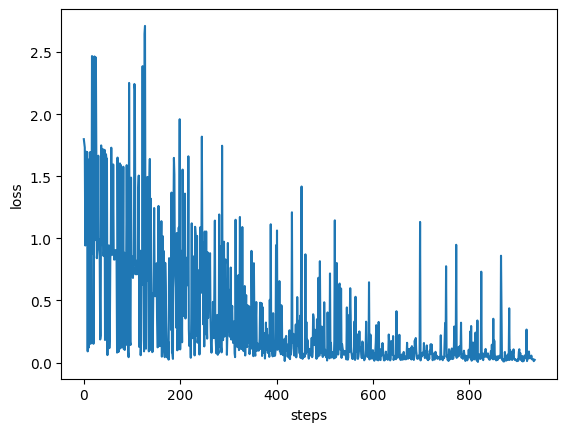

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lineplot(x=range(len(logs['loss'])), y=logs['loss'])
plt.xlabel('steps')
plt.ylabel('loss')
plt.show()

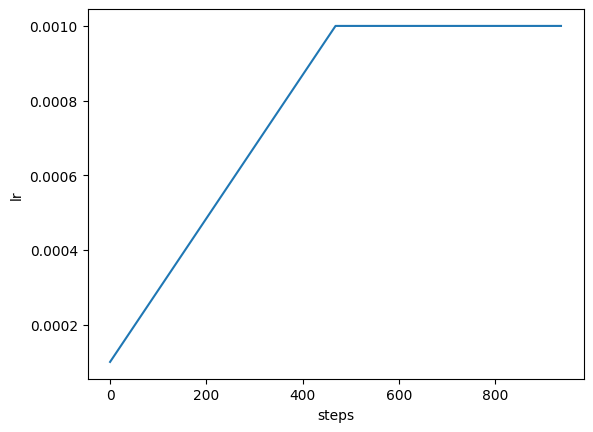

In [91]:
sns.lineplot(x=range(len(logs['lr'])), y=logs['lr'])
plt.xlabel('steps')
plt.ylabel('lr')
plt.show()

---

## Validate:

In [92]:
def my_agent(obs, env_config):
    assert env_config.rows == 6
    assert env_config.columns == 7
    assert env_config.inarow == 4

    moves = Q_func(process_state(obs, device)[None,:])[0]
    mask_board = torch.tensor(obs.board[:env_config.columns], dtype=bool, device=device)

    action = torch.masked_fill(moves, mask_board, -float('inf')).argmax().item()
    print('action:', action)
    return action


In [93]:
from kaggle_environments import evaluate

def mean_reward(rewards):
    return sum(r[0] for r in rewards) / float(len(rewards))

# Run multiple episodes to estimate its performance.
# print("My Agent vs Random Agent:", mean_reward(evaluate("connectx", [my_agent, "random"], num_episodes=100)))
print("My Agent vs Negamax Agent:", mean_reward(evaluate("connectx", [my_agent, "negamax"], num_episodes=100)))

My Agent vs Negamax Agent: -1.0


In [95]:
print("My Agent vs Random Agent:", mean_reward(evaluate("connectx", [my_agent, "random"], num_episodes=100)))

My Agent vs Random Agent: 0.54
